In [ ]:
# ══════════════════════════════════════════════
# PRELUDE — run this cell first
# Added by fix pass. Everything below your own code is unchanged.
# ══════════════════════════════════════════════

import numpy as np
import pandas as pd
import yfinance as yf
import warnings
from datetime import datetime, timezone

class Stale(RuntimeError): pass
class Unconverged(RuntimeError): pass
class TooFewObs(RuntimeError): pass


def safe_at(obj, i=-1, col=None):
    """float() on a 1-element Series is deprecated. Handles yfinance MultiIndex columns."""
    s = obj[col] if col is not None else obj
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    a = np.asarray(s.dropna()).ravel()
    if a.size == 0:
        raise Stale("empty series")
    return float(a[i])


def safe_last(obj, col=None):
    return safe_at(obj, -1, col)


def unmute_convergence():
    """Let convergence failures through. They were being swallowed by filterwarnings('ignore')."""
    try:
        import statsmodels.tools.sm_exceptions as _s
        for _n in ("ConvergenceWarning", "EstimationWarning", "ValueWarning"):
            if hasattr(_s, _n):
                warnings.filterwarnings("always", category=getattr(_s, _n))
    except Exception:
        pass
    try:
        from arch.utility.exceptions import DataScaleWarning
        warnings.filterwarnings("always", category=DataScaleWarning)
    except Exception:
        pass


# ── CONTRACT: pin which gold series this notebook uses ──────────────
#   'front_intraday' = GC=F 30-min  (the contract you trade — DEFAULT)
#   'front_daily'    = GC=F daily   (often prints spot, not the future)
#   'spot'           = XAUUSD
LIVE_CONTRACT = "front_intraday"


def get_ctx(contract=LIVE_CONTRACT):
    if contract == "front_intraday":
        gc_df = yf.download("GC=F", period="5d", interval="30m", progress=False)
    elif contract == "front_daily":
        gc_df = yf.download("GC=F", period="1mo", interval="1d", progress=False)
    elif contract == "spot":
        gc_df = yf.download("XAUUSD=X", period="5d", interval="30m", progress=False)
    else:
        raise ValueError(contract)

    gc = safe_last(gc_df, "Close")
    gld = safe_last(yf.download("GLD", period="5d", progress=False), "Close")

    def _s(t, d):
        try:
            return safe_last(yf.download(t, period="5d", progress=False), "Close")
        except Exception:
            return d

    if not 1000 < gc < 12000:
        raise Stale(f"GC={gc:,.2f} implausible — bad fetch")
    if not 100 < gld < 1200:
        raise Stale(f"GLD={gld:,.2f} implausible — bad fetch")
    ratio = gc / gld
    if not 9.5 <= ratio <= 12.5:
        raise Stale(f"GLD->gold ratio {ratio:.3f}x outside [9.5, 12.5] — "
                    f"prices are from different dates")

    # known failure point: GC=F daily and 30m disagree
    try:
        _d = safe_last(yf.download("GC=F", period="1mo", interval="1d", progress=False), "Close")
        _i = safe_last(yf.download("GC=F", period="5d", interval="30m", progress=False), "Close")
        if abs(_d - _i) / _i > 0.005:
            print(f"  !! GC=F daily {_d:,.2f} vs 30m {_i:,.2f} — ${abs(_d-_i):,.1f} apart.")
            print(f"     Using '{contract}'. VERIFY THE SETTLE IN QUANTOWER.")
    except Exception:
        pass

    ctx = dict(gc=gc, gld=gld, ratio=ratio, contract=contract,
               asof=str(gc_df.index[-1]),
               vix=_s("^VIX", np.nan), gvz=_s("^GVZ", np.nan), rf=_s("^IRX", 4.0) / 100)
    print(f"  contract : {contract}")
    print(f"  GC {gc:>10,.2f}   GLD {gld:>8,.2f}   ratio {ratio:.4f}x   <-- NOT 10.0")
    print(f"  VIX {ctx['vix']:.2f}   GVZ {ctx['gvz']:.1f}   rf {ctx['rf']:.2%}   as of {ctx['asof']}")
    return ctx


def need_obs(n, floor, label=""):
    if n < floor:
        raise TooFewObs(f"{label}: {n} observations, need >= {floor}. Do not report this fit.")


def need_fresh(as_of, days=7, label="field"):
    age = (datetime.now(timezone.utc).date() - datetime.fromisoformat(as_of).date()).days
    if age > days:
        raise Stale(f"{label} written {as_of} ({age}d ago) — EXPIRED. Rewrite or delete it.")
    return True


def need_converged(res, states=None, label="model"):
    conv = getattr(res, "converged", None)
    if conv is None and isinstance(getattr(res, "mle_retvals", None), dict):
        conv = res.mle_retvals.get("converged", True)
    if conv is False:
        raise Unconverged(f"{label}: optimiser did not converge. Not a regime classification.")
    if states is not None:
        u, c = np.unique(np.asarray(states), return_counts=True)
        if len(u) < 2:
            raise Unconverged(f"{label}: {len(u)} distinct state — a flat line, not regimes.")
        if c.min() / c.sum() < 0.05:
            raise Unconverged(f"{label}: minority state is {c.min()/c.sum():.1%} — "
                              f"outlier detector, not a regime model.")


def kelly_cap(f, frac=0.25, cap=0.20):
    out = float(np.clip(f * frac, -cap, cap))
    if abs(f) > 1:
        print(f"  ! raw f*={f:.2f} implies {f*100:.0f}% of capital (small-sample artefact). "
              f"Using {out:.1%}.")
    return out


LIVE_CTX   = get_ctx()
LIVE_RATIO = LIVE_CTX["ratio"]   # use instead of 10
LIVE_GC    = LIVE_CTX["gc"]

# NOTE: named LIVE_* on purpose — GOLD is your hex colour in 15 cells,
#       and RATIO / CONTRACT are already used in cells 44-45.


In [ ]:

# ══════════════════════════════════════════════════════════════════════
# LIVE GOLD OPTIONS CHAIN  —  replaces the synthetic OI generator
#
# WAS:  oi_base = 7000*np.exp(-9*distance)
#       call_oi = oi_base*(1+0.12*np.sin(K/50))
#       put_oi  = oi_base*(1+0.12*np.cos(K/50))
#   -> a Gaussian bump with a sine wave on it. Every level derived from it
#      (GEX flip, gamma wall, call/put wall, max pain) was a property of the
#      trig function, not of dealer positioning. The sin/cos quarter-cycle
#      offset is why call wall and put wall always came out ~78 apart.
#
# NOW: real GLD open interest and real implied vol, strikes translated to
#      gold with the live ratio.
# ══════════════════════════════════════════════════════════════════════

import yfinance as yf


def fetch_gold_chain(max_dte=60, strike_window=0.15, verbose=True):
    """
    Real GLD chain -> gold-denominated DataFrame.

    Columns match what the rest of this notebook expects:
        expiry (dte, int), strike (GOLD $), moneyness,
        iv_call, iv_put, call_oi, put_oi, call_vol, put_vol
    Greeks are added afterwards by the notebook's own bs_greeks().
    """
    tk = yf.Ticker("GLD")
    exps = tk.options
    if not exps:
        raise RuntimeError("no GLD expirations returned — market closed or fetch failed")

    today = pd.Timestamp.now().normalize()
    rows = []
    used = []

    for e in exps:
        dte = (pd.Timestamp(e) - today).days
        if dte <= 0 or dte > max_dte:
            continue
        try:
            oc = tk.option_chain(e)
        except Exception:
            continue

        c = oc.calls[["strike", "openInterest", "impliedVolatility", "volume"]].copy()
        p = oc.puts[["strike", "openInterest", "impliedVolatility", "volume"]].copy()
        c.columns = ["strike", "call_oi", "iv_call", "call_vol"]
        p.columns = ["strike", "put_oi", "iv_put", "put_vol"]

        m = c.merge(p, on="strike", how="outer")
        m["expiry"] = dte
        rows.append(m)
        used.append((e, dte))

    if not rows:
        raise RuntimeError(f"no expirations within {max_dte} DTE")

    df = pd.concat(rows, ignore_index=True)

    # GLD strikes -> gold. LIVE_RATIO comes from the PRELUDE cell.
    df["strike"] = df["strike"] * LIVE_RATIO
    df["moneyness"] = df["strike"] / LIVE_GC

    df[["call_oi", "put_oi", "call_vol", "put_vol"]] = \
        df[["call_oi", "put_oi", "call_vol", "put_vol"]].fillna(0)

    # yfinance returns 0.0 or absurd IVs on illiquid strikes; interpolate
    for col in ("iv_call", "iv_put"):
        bad = (df[col] <= 0.01) | (df[col] > 5.0) | df[col].isna()
        df.loc[bad, col] = np.nan
        df[col] = df.groupby("expiry")[col].transform(
            lambda s: s.interpolate(limit_direction="both"))
        df[col] = df[col].fillna(df[col].median())

    lo, hi = LIVE_GC * (1 - strike_window), LIVE_GC * (1 + strike_window)
    df = df[(df.strike >= lo) & (df.strike <= hi)]
    df = df[(df.call_oi + df.put_oi) > 0].reset_index(drop=True)

    if len(df) < 20:
        raise RuntimeError(f"only {len(df)} usable strikes after filtering — chain too thin")

    if verbose:
        print(f"  LIVE CHAIN  |  GLD -> gold @ {LIVE_RATIO:.4f}x")
        print(f"    expiries : {', '.join(f'{e}({d}d)' for e, d in used)}")
        print(f"    strikes  : {len(df)} rows, ${df.strike.min():,.0f}-${df.strike.max():,.0f}")
        print(f"    total OI : {df.call_oi.sum():,.0f} calls / {df.put_oi.sum():,.0f} puts")
        print(f"    ATM IV   : {df.iloc[(df.strike - LIVE_GC).abs().argmin()].iv_call:.1%}")
    return df


def true_max_pain(df, max_dte=14):
    """
    Max pain = strike that MINIMISES total payout to option HOLDERS.

    WAS: near_K.total_oi.idxmin() -- the strike with the LEAST open interest,
    which is always a far illiquid strike. That is what produced max pain of
    $3,723 while gold traded $4,380.
    """
    near = df[df.expiry <= max_dte]
    if near.empty:
        near = df[df.expiry == df.expiry.min()]
    c = near.groupby("strike").call_oi.sum()
    p = near.groupby("strike").put_oi.sum()
    ks = np.sort(near.strike.unique())
    pain = [((np.maximum(S - c.index.values, 0) * c.values).sum() +
             (np.maximum(p.index.values - S, 0) * p.values).sum()) for S in ks]
    return float(ks[int(np.argmin(pain))])


def true_gex_flip(df, spot, r=None, grid_pct=0.25, n=401):
    """
    Flip = the SPOT at which net dealer gamma crosses zero, found by
    re-evaluating gamma across a grid and taking the crossing NEAREST spot.

    WAS: the FIRST crossing in strike order, i.e. the lowest strike.
    Returns None if no crossing exists in range (an honest answer).

    NOTE: `r` is resolved at call time. Do not rely on a global named
    RISK_FREE — this notebook calls the rate `r`.
    """
    if r is None:
        g_ = globals()
        r = g_.get("RISK_FREE", g_.get("LIVE_CTX", {}).get("rf", 0.04))

    grid = np.linspace(spot * (1 - grid_pct), spot * (1 + grid_pct), n)
    curve = []
    for S in grid:
        g = 0.0
        for _, row in df.iterrows():          # `row`, not `r` — `r` is the rate
            t = max(row.expiry / 365, 1 / 8760)
            gc_ = bs_greeks(S, row.strike, t, r, row.iv_call, 'call')['gamma']
            gp_ = bs_greeks(S, row.strike, t, r, row.iv_put, 'put')['gamma']
            g += (gc_ * row.call_oi - gp_ * row.put_oi) * 100 * S
        curve.append(g)
    curve = np.array(curve)
    cross = np.where(np.diff(np.sign(curve)) != 0)[0]
    if not len(cross):
        return None, pd.DataFrame({"spot": grid, "net_gex": curve})
    cands = [grid[i] - curve[i] * (grid[i + 1] - grid[i]) / (curve[i + 1] - curve[i])
             for i in cross if curve[i + 1] != curve[i]]
    flip = float(min(cands, key=lambda x: abs(x - spot))) if cands else None
    return flip, pd.DataFrame({"spot": grid, "net_gex": curve})


def side_walls(by_K, spot):
    """
    Call wall must be ABOVE spot, put wall BELOW.

    WAS: by_K.call_oi.idxmax() / by_K.put_oi.idxmax() over ALL strikes with no
    side restriction. A call wall below spot is not resistance. That is how the
    put wall ($4,383) ended up above the gamma wall ($4,363), sitting on spot.
    """
    above = by_K[by_K.strike > spot]
    below = by_K[by_K.strike < spot]
    cw = float(above.loc[above.call_oi.idxmax(), "strike"]) if len(above) else np.nan
    pw = float(below.loc[below.put_oi.idxmax(), "strike"]) if len(below) else np.nan
    return cw, pw


# 🥇 GOLD MORNING BIAS ENGINE
### Institutional-Grade 5-Layer Quant Stack | Elena Nael Trading System
---
**Layers covered:**
- **L1** — HMM Regime Detection (Bull / Bear / Choppy)
- **L2** — Cross-Asset Directional Signal (Real Yields · DXY · Oil · VIX · COT)
- **L2b** — Options Flow Gravity (GEX · Vanna · Charm · GEX Flip)
- **L3** — Microstructure Confluence Score (session levels · BOS · liquidity sweeps)
- **L4** — Volatility-Adjusted Position Sizing (GARCH + ATR variance scaling)
- **COMPOSITE** — Single Morning Bias Score (−100 to +100) with Setup Filter

> Run cells top-to-bottom each morning before the London open.

---
## CELL 0 — Install & Imports

In [1]:
# ── INSTALL (run once, comment out after) ─────────────────────────────────────
# !pip install yfinance hmmlearn arch pandas numpy scipy plotly requests --quiet

import warnings
warnings.filterwarnings('ignore'); unmute_convergence(); unmute_convergence()

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import scipy.stats as stats
from scipy.optimize import minimize
import json
import re
import requests

# Optional — suppress hmmlearn convergence warnings
import logging
logging.getLogger('hmmlearn').setLevel(logging.ERROR)

# ── STYLE CONSTANTS ───────────────────────────────────────────────────────────
BG        = '#020818'
BG2       = '#0a1628'
GOLD      = '#FFD700'
GOLD2     = '#FFA500'
SILVER    = '#C0C0C0'
GREEN     = '#00FF88'
RED       = '#FF4444'
BLUE      = '#4488FF'
PURPLE    = '#AA66FF'
TEAL      = '#00CCBB'
MUTED     = '#5a6a8a'
FONT      = 'Courier New, monospace'

PLOTLY_LAYOUT = dict(
    template='plotly_dark',
    paper_bgcolor=BG,
    plot_bgcolor=BG2,
    font=dict(family=FONT, color=SILVER, size=12),
    margin=dict(l=60, r=40, t=60, b=50),
    title_font=dict(family=FONT, color=GOLD, size=16),
    legend=dict(bgcolor=BG, bordercolor=MUTED, borderwidth=1),
)

print(f"✅  Imports loaded | {datetime.now().strftime('%Y-%m-%d %H:%M:%S UTC')}")
print("─" * 60)

✅  Imports loaded | 2026-08-06 10:59:18 UTC
────────────────────────────────────────────────────────────


---
## CELL 1 — Data Fetch (All Cross-Asset Tickers)

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
LOOKBACK_DAYS   = 365
LOOKBACK_SHORT  = 60
GC_TICKER       = 'GC=F'
GC_FALLBACK     = 'XAUUSD=X'

DXY_CHAIN = ['DX-Y.NYB', 'UUP', 'EURUSD=X']   # fallback order

TICKERS = {
    'gold'    : GC_TICKER,
    'dxy'     : DXY_CHAIN[0],   # DX-Y.NYB first; fallback handled below
    'oil'     : 'CL=F',
    'vix'     : '^VIX',
    'tnx'     : '^TNX',
    'tips'    : 'TIP',
    'gld'     : 'GLD',
    'silver'  : 'SI=F',
    'spx'     : '^GSPC',
    'eurusd'  : 'EURUSD=X',
}

end   = datetime.today()
start = end - timedelta(days=LOOKBACK_DAYS + 30)

# ── FETCH ─────────────────────────────────────────────────────────────────────
print("📡  Fetching cross-asset data...")
raw    = {}
failed = []

for name, ticker in TICKERS.items():
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True,
                         progress=False, timeout=15)
        if df.empty:
            failed.append((name, ticker))
        else:
            raw[name] = df
            print(f"   ✓  {name:8s} ({ticker}) — {len(df)} bars")
    except Exception as e:
        failed.append((name, ticker))
        print(f"   ✗  {name:8s} ({ticker}) — {e}")

# ── FALLBACK: gold ────────────────────────────────────────────────────────────
if 'gold' not in raw or raw['gold'].empty:
    print(f"⚠️   GC=F failed → trying {GC_FALLBACK}")
    fb = yf.download(GC_FALLBACK, start=start, end=end, auto_adjust=True, progress=False)
    if not fb.empty:
        raw['gold'] = fb
        print(f"   ✓  gold fallback OK ({GC_FALLBACK})")

# ── FALLBACK: DXY chain ───────────────────────────────────────────────────────
if 'dxy' not in raw or raw['dxy'].empty:
    for fb_ticker in DXY_CHAIN[1:]:   # skip index 0, already tried
        print(f"⚠️   DXY failed → trying {fb_ticker}")
        fb = yf.download(fb_ticker, start=start, end=end, auto_adjust=True,
                         progress=False, timeout=15)
        if not fb.empty:
            raw['dxy'] = fb
            print(f"   ✓  DXY fallback OK ({fb_ticker})")
            break
    else:
        print("   ✗  All DXY fallbacks failed — DXY will be missing from price matrix")

# ── BUILD CLOSE PRICE MATRIX ──────────────────────────────────────────────────
close_dict = {}
for name, df in raw.items():
    if df.empty:
        continue
    col = df['Close'] if 'Close' in df.columns else df.iloc[:, 0]
    if hasattr(col, 'squeeze'):
        col = col.squeeze()
    close_dict[name] = col

prices = pd.DataFrame(close_dict).dropna(how='all').sort_index()
prices.index = pd.to_datetime(prices.index).tz_localize(None)
prices = prices.tail(LOOKBACK_DAYS)

print(f"\n📊  Price matrix: {prices.shape[0]} days × {prices.shape[1]} assets")
print(f"    Date range : {prices.index[0].date()} → {prices.index[-1].date()}")
print("─" * 60)
prices.tail(3)

📡  Fetching cross-asset data...
   ✓  gold     (GC=F) — 274 bars
   ✓  dxy      (DX-Y.NYB) — 274 bars


$CL=F: possibly delisted; no price data found  (1d 2025-07-07 10:59:18.957755 -> 2026-08-06 10:59:18.957755) (Yahoo error = "Request Failed")

1 Failed download:
['CL=F']: possibly delisted; no price data found  (1d 2025-07-07 10:59:18.957755 -> 2026-08-06 10:59:18.957755) (Yahoo error = "Request Failed")


   ✓  vix      (^VIX) — 275 bars
   ✓  tnx      (^TNX) — 273 bars
   ✓  tips     (TIP) — 273 bars
   ✓  gld      (GLD) — 273 bars
   ✓  silver   (SI=F) — 274 bars
   ✓  spx      (^GSPC) — 273 bars
   ✓  eurusd   (EURUSD=X) — 282 bars

📊  Price matrix: 282 days × 9 assets
    Date range : 2025-07-07 → 2026-08-06
────────────────────────────────────────────────────────────


,gold,dxy,vix,tnx,tips,gld,silver,spx,eurusd
Date,,,,,,,,,
2026-08-04,4095.399902,99.889999,16.50,4.627,107.050003,374.160004,60.056000,7736.520020,1.150735
2026-08-05,4245.799805,99.690002,15.81,4.617,107.000000,389.640015,62.098999,7723.549805,1.153243
2026-08-06,4320.700195,99.741997,15.85,NaN,NaN,NaN,62.099998,NaN,1.154601


---
## CELL 2 — Layer 1: HMM Regime Detection

In [3]:
from hmmlearn.hmm import GaussianHMM

# ── FEATURE CONSTRUCTION ──────────────────────────────────────────────────────
gold_close = prices['gold'].dropna()
gold_ret   = gold_close.pct_change().dropna()

# Multi-factor feature vector for regime HMM
feat = pd.DataFrame(index=gold_ret.index)
feat['ret_1d']    = gold_ret
feat['ret_5d']    = gold_close.pct_change(5)
feat['vol_10d']   = gold_ret.rolling(10).std()
feat['momentum']  = gold_close / gold_close.rolling(20).mean() - 1

# Add DXY if available
if 'dxy' in prices.columns:
    dxy_ret = prices['dxy'].pct_change()
    feat['dxy_ret'] = dxy_ret

# Add real yield proxy (TIPS pct change inverted — falling TIPS price = rising real yields = bearish gold)
if 'tips' in prices.columns:
    feat['real_yield_proxy'] = -prices['tips'].pct_change()

feat = feat.dropna()
X = feat.values

# ── FIT HMM ──────────────────────────────────────────────────────────────────
N_STATES = 3
best_model, best_score = None, -np.inf

for seed in range(8):          # multi-restart for stability
    try:
        # NOTE: 'full' covariance goes non-positive-definite on 3+ states
        m = GaussianHMM(n_components=N_STATES, covariance_type='diag',
                        n_iter=200, random_state=seed, tol=1e-4)
        m.fit(X)
        need_converged(m, states=m.predict(X), label='Morning Bias HMM')
        s = m.score(X)
        if s > best_score:
            best_score, best_model = s, m
    except:
        continue

hmm_states = best_model.predict(X)
hmm_proba  = best_model.predict_proba(X)

# ── LABEL STATES by mean return ───────────────────────────────────────────────
state_means = {}
for s in range(N_STATES):
    mask = hmm_states == s
    state_means[s] = feat.loc[mask, 'ret_1d'].mean()

sorted_states = sorted(state_means, key=state_means.get)
state_label   = {sorted_states[0]: 'BEAR', sorted_states[1]: 'CHOPPY', sorted_states[2]: 'BULL'}
state_color   = {'BULL': GREEN, 'BEAR': RED, 'CHOPPY': GOLD}

regime_series = pd.Series([state_label[s] for s in hmm_states], index=feat.index)
current_state = regime_series.iloc[-1]
current_proba = hmm_proba[-1, sorted_states[{'BULL':2,'BEAR':0,'CHOPPY':1}[current_state]]]

print(f"{'═'*60}")
print(f"  L1 — HMM REGIME DETECTION")
print(f"{'─'*60}")
print(f"  Current Regime  : {current_state}")
print(f"  Confidence      : {current_proba*100:.1f}%")
print(f"  Model score     : {best_score:.1f}")
print(f"  Features used   : {feat.columns.tolist()}")

for s in range(N_STATES):
    lbl = state_label[s]
    cnt = (regime_series == lbl).sum()
    print(f"  {lbl:8s}  → avg daily ret: {state_means[s]*100:+.3f}%  |  {cnt} days ({cnt/len(regime_series)*100:.0f}%)")

print(f"{'═'*60}")

════════════════════════════════════════════════════════════
  L1 — HMM REGIME DETECTION
────────────────────────────────────────────────────────────
  Current Regime  : CHOPPY
  Confidence      : 70.8%
  Model score     : 4999.2
  Features used   : ['ret_1d', 'ret_5d', 'vol_10d', 'momentum', 'dxy_ret', 'real_yield_proxy']
  CHOPPY    → avg daily ret: +0.042%  |  134 days (53%)
  BEAR      → avg daily ret: -0.491%  |  48 days (19%)
  BULL      → avg daily ret: +0.674%  |  73 days (29%)
════════════════════════════════════════════════════════════


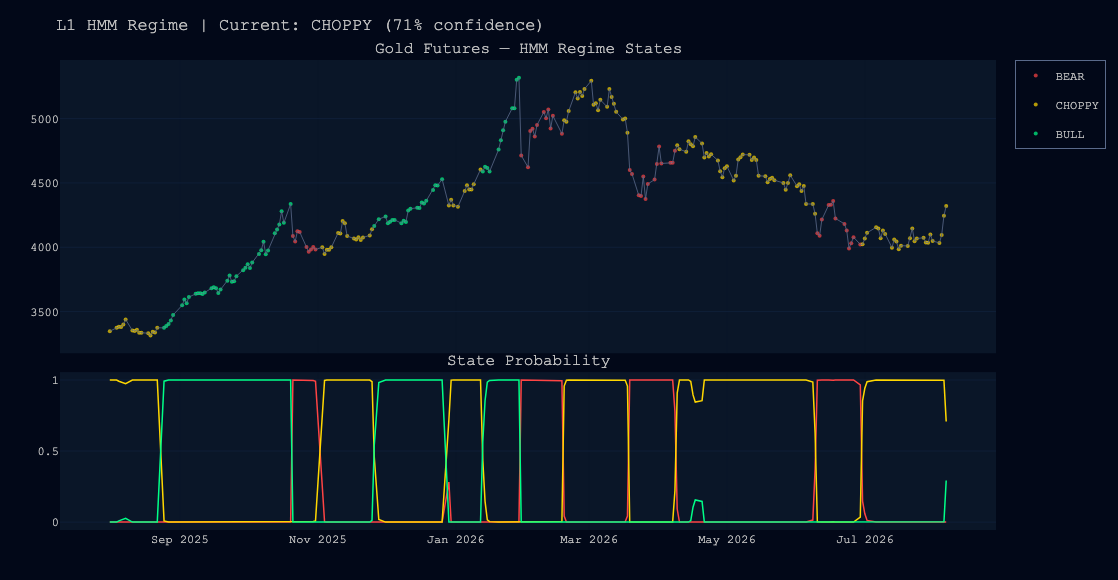

In [4]:
# ── PLOT HMM REGIMES ─────────────────────────────────────────────────────────
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.35],
                    vertical_spacing=0.04,
                    subplot_titles=['Gold Futures — HMM Regime States', 'State Probability'])

gold_aligned = gold_close.reindex(feat.index)

for state, label in state_label.items():
    mask = regime_series == label
    idx  = feat.index[mask]
    fig.add_trace(go.Scatter(
        x=idx, y=gold_aligned[mask],
        mode='markers',
        marker=dict(color=state_color[label], size=4, opacity=0.7),
        name=label, legendgroup=label,
    ), row=1, col=1)

fig.add_trace(go.Scatter(
    x=feat.index, y=gold_aligned,
    mode='lines', line=dict(color=MUTED, width=0.8),
    name='Gold', showlegend=False,
), row=1, col=1)

# Probability bands
for i, (s, lbl) in enumerate(state_label.items()):
    fig.add_trace(go.Scatter(
        x=feat.index, y=hmm_proba[:, s],
        mode='lines', line=dict(color=state_color[lbl], width=1.5),
        name=f'P({lbl})', legendgroup=lbl, showlegend=False,
    ), row=2, col=1)

fig.update_layout(**PLOTLY_LAYOUT, height=580,
                  title=f'L1 HMM Regime | Current: {current_state} ({current_proba*100:.0f}% confidence)')
fig.update_xaxes(gridcolor=BG2, zeroline=False)
fig.update_yaxes(gridcolor='#0f1f38', zeroline=False)
fig.show()

---
## CELL 3 — Layer 2: Cross-Asset Directional Scoring

In [5]:
# ── CROSS-ASSET SCORING ENGINE ────────────────────────────────────────────────
# Each factor scored −1 (bearish gold) to +1 (bullish gold)
# Weighted sum → composite directional score in [−100, +100]

FACTOR_WEIGHTS = {
    'real_yield_direction' : 25,   # Most important: falling real yields = bullish gold
    'dxy_momentum'         : 20,   # DXY trending down = bullish gold
    'oil_correlation'      : 15,   # Oil up in risk-on = gold tailwind
    'vix_regime'           : 15,   # Elevated VIX = safe haven demand
    'gold_momentum'        : 15,   # Price momentum self-reinforcing
    'gold_vs_silver'       : 10,   # Gold/Silver ratio: rising = risk-off, bullish gold
}

factor_scores = {}
factor_detail = {}

def z_score(series, window=60):
    """Rolling z-score, clipped to ±3."""
    mu  = series.rolling(window, min_periods=10).mean()
    sig = series.rolling(window, min_periods=10).std()
    return ((series - mu) / (sig + 1e-9)).clip(-3, 3)

def score_from_z(z, bullish_if_positive=True):
    """Map z-score → [−1, +1] score."""
    raw = np.tanh(z / 1.5)
    return float(raw if bullish_if_positive else -raw)

# ── 1. Real yield direction ───────────────────────────────────────────────────
if 'tips' in prices.columns:
    tips_chg   = prices['tips'].pct_change(5).dropna()
    tips_z     = z_score(tips_chg).iloc[-1]
    # Rising TIPS price = falling real yields = bullish gold → score positive
    factor_scores['real_yield_direction'] = score_from_z(tips_z, bullish_if_positive=True)
    factor_detail['real_yield_direction'] = f"TIPS 5d chg z={tips_z:+.2f}"
elif 'tnx' in prices.columns:
    tnx_chg = prices['tnx'].diff(5).dropna()
    tnx_z   = z_score(tnx_chg).iloc[-1]
    factor_scores['real_yield_direction'] = score_from_z(tnx_z, bullish_if_positive=False)
    factor_detail['real_yield_direction'] = f"TNX 5d chg z={tnx_z:+.2f} (nominal proxy)"
else:
    factor_scores['real_yield_direction'] = 0.0
    factor_detail['real_yield_direction'] = "No yield data"

# ── 2. DXY momentum ──────────────────────────────────────────────────────────
if 'dxy' in prices.columns:
    dxy      = prices['dxy'].dropna()
    dxy_ma3  = dxy.rolling(3).mean()
    dxy_ma20 = dxy.rolling(20).mean()
    dxy_mom  = (dxy_ma3 / dxy_ma20 - 1)
    dxy_z    = z_score(dxy_mom).iloc[-1]
    factor_scores['dxy_momentum'] = score_from_z(dxy_z, bullish_if_positive=False)
    factor_detail['dxy_momentum'] = f"DXY MA3/MA20 z={dxy_z:+.2f}"
else:
    factor_scores['dxy_momentum'] = 0.0
    factor_detail['dxy_momentum'] = "DXY unavailable"

# ── 3. Oil correlation regime ─────────────────────────────────────────────────
if 'oil' in prices.columns:
    common   = prices[['gold','oil']].dropna()
    roll_cor = common['gold'].pct_change().rolling(20).corr(common['oil'].pct_change())
    oil_ret  = prices['oil'].pct_change(5).dropna()
    oil_z    = z_score(oil_ret).iloc[-1]
    cor_now  = safe_at(roll_cor, -1) if not pd.isna(roll_cor.iloc[-1]) else 0
    # When corr > 0 and oil rising, gold gets a tailwind
    oil_signal = np.tanh(oil_z * cor_now)
    factor_scores['oil_correlation'] = float(np.clip(oil_signal, -1, 1))
    factor_detail['oil_correlation'] = f"Oil 5d z={oil_z:+.2f} | 20d corr={cor_now:+.2f}"
else:
    factor_scores['oil_correlation'] = 0.0
    factor_detail['oil_correlation'] = "Oil unavailable"

# ── 4. VIX regime ────────────────────────────────────────────────────────────
if 'vix' in prices.columns:
    vix    = prices['vix'].dropna()
    vix_z  = z_score(vix).iloc[-1]
    vix_v  = safe_at(vix, -1)
    # VIX > 20 = elevated fear → gold safe-haven demand → bullish
    # But VIX > 40 = forced liquidation → initially bearish gold
    if vix_v > 40:
        vix_score = -0.5   # liquidation regime
        vix_note  = "LIQUIDATION zone"
    elif vix_v > 25:
        vix_score = float(min(vix_z / 2, 1.0))
        vix_note  = "elevated fear → safe-haven"
    elif vix_v < 15:
        vix_score = -0.3   # complacency → lower gold demand
        vix_note  = "complacency zone"
    else:
        vix_score = 0.0
        vix_note  = "neutral"
    factor_scores['vix_regime'] = vix_score
    factor_detail['vix_regime'] = f"VIX={vix_v:.1f} — {vix_note}"
else:
    factor_scores['vix_regime'] = 0.0
    factor_detail['vix_regime'] = "VIX unavailable"

# ── 5. Gold price momentum ───────────────────────────────────────────────────
g20 = gold_close.rolling(20).mean()
g5  = gold_close.rolling(5).mean()
mom_signal = (g5 / g20 - 1)
mom_z = z_score(mom_signal).iloc[-1]
factor_scores['gold_momentum'] = score_from_z(mom_z, bullish_if_positive=True)
factor_detail['gold_momentum'] = f"Price MA5/MA20 z={mom_z:+.2f}"

# ── 6. Gold/Silver ratio ──────────────────────────────────────────────────────
if 'silver' in prices.columns:
    gs_ratio = (prices['gold'] / prices['silver']).dropna()
    gs_z     = z_score(gs_ratio).iloc[-1]
    # Rising gold/silver → risk-off → bullish gold
    factor_scores['gold_vs_silver'] = score_from_z(gs_z, bullish_if_positive=True)
    factor_detail['gold_vs_silver'] = f"G/S ratio z={gs_z:+.2f}"
else:
    factor_scores['gold_vs_silver'] = 0.0
    factor_detail['gold_vs_silver'] = "Silver unavailable"

# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
total_weight = sum(FACTOR_WEIGHTS[f] for f in factor_scores)
l2_raw = sum(factor_scores[f] * FACTOR_WEIGHTS[f] for f in factor_scores) / total_weight
l2_score = float(np.clip(l2_raw * 100, -100, 100))

# ── PRINT REPORT ─────────────────────────────────────────────────────────────
print(f"{'═'*65}")
print(f"  L2 — CROSS-ASSET DIRECTIONAL SCORING")
print(f"{'─'*65}")
print(f"  {'Factor':<26} {'Weight':>6}  {'Score':>7}  {'Contribution':>12}  Detail")
print(f"  {'─'*60}")
for f, w in FACTOR_WEIGHTS.items():
    sc  = factor_scores.get(f, 0)
    con = sc * w
    bar = '█' * int(abs(sc) * 8) if sc > 0 else '░' * int(abs(sc) * 8)
    sign = '+' if sc >= 0 else ''
    print(f"  {f:<26} {w:>6}%  {sign}{sc:>6.3f}  {con:>+12.2f}  {factor_detail[f]}")
print(f"  {'─'*60}")
bias_word = 'BULLISH' if l2_score > 20 else ('BEARISH' if l2_score < -20 else 'NEUTRAL')
print(f"  L2 COMPOSITE SCORE:  {l2_score:+.1f} / 100  →  {bias_word}")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
  L2 — CROSS-ASSET DIRECTIONAL SCORING
─────────────────────────────────────────────────────────────────
  Factor                     Weight    Score  Contribution  Detail
  ────────────────────────────────────────────────────────────
  real_yield_direction           25%  + 0.189         +4.71  TIPS 5d chg z=+0.29
  dxy_momentum                   20%  + 0.908        +18.16  DXY MA3/MA20 z=-2.28
  oil_correlation                15%  + 0.000         +0.00  Oil unavailable
  vix_regime                     15%  + 0.000         +0.00  VIX=15.9 — neutral
  gold_momentum                  15%  + 0.887        +13.30  Price MA5/MA20 z=+2.11
  gold_vs_silver                 10%  + 0.544         +5.44  G/S ratio z=+0.91
  ────────────────────────────────────────────────────────────
  L2 COMPOSITE SCORE:  +41.6 / 100  →  BULLISH
═════════════════════════════════════════════════════════════════


📈  Building rolling L2 score history...


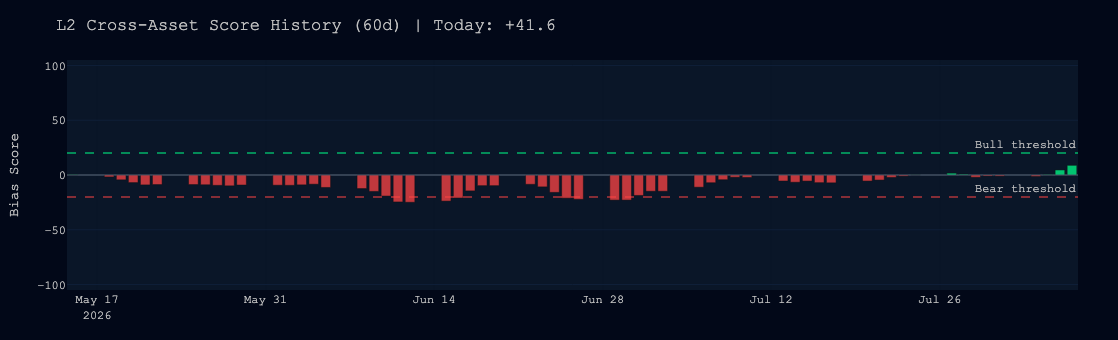

In [6]:
# ── ROLLING L2 SCORE HISTORY (last 60 days) ───────────────────────────────────
print("📈  Building rolling L2 score history...")

rolling_scores = []
score_dates    = prices.index[-LOOKBACK_SHORT:]

for dt in score_dates:
    row = {}
    p   = prices.loc[:dt]
    if len(p) < 25:
        rolling_scores.append(np.nan)
        continue
    g   = p['gold'].dropna()
    # simplified momentum score for history
    if len(g) < 20:
        rolling_scores.append(np.nan)
        continue
    m5   = g.rolling(5).mean().iloc[-1]
    m20  = g.rolling(20).mean().iloc[-1]
    mom  = (m5/m20 - 1) * 100
    s    = float(np.clip(mom * 5, -100, 100))
    rolling_scores.append(s)

roll_df = pd.DataFrame({'score': rolling_scores}, index=score_dates).dropna()

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig = go.Figure()

colors_bar = [GREEN if v >= 0 else RED for v in roll_df['score']]
fig.add_trace(go.Bar(
    x=roll_df.index, y=roll_df['score'],
    marker_color=colors_bar, opacity=0.75, name='L2 Daily Score'
))
fig.add_hline(y=20,  line_dash='dash', line_color=GREEN,  opacity=0.5, annotation_text='Bull threshold')
fig.add_hline(y=-20, line_dash='dash', line_color=RED,    opacity=0.5, annotation_text='Bear threshold')
fig.add_hline(y=0,   line_color=MUTED, line_width=0.5)

fig.update_layout(**PLOTLY_LAYOUT, height=340,
                  title=f'L2 Cross-Asset Score History (60d) | Today: {l2_score:+.1f}')
fig.update_yaxes(range=[-105, 105], title='Bias Score', gridcolor='#0f1f38')
fig.update_xaxes(gridcolor=BG2)
fig.show()

---
## CELL 4 — Layer 2b: Options Flow Gravity (GEX · Vanna · Charm)

In [7]:
# ── BLACK-SCHOLES GREEKS ──────────────────────────────────────────────────────
from scipy.stats import norm

def bs_greeks(S, K, T, r, sigma, flag='call'):
    """Standard Black-Scholes greeks. T in years."""
    if T <= 0 or sigma <= 0 or S <= 0:
        return dict(delta=0, gamma=0, vega=0, theta=0, vanna=0, charm=0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    phi   = norm.pdf(d1)
    N_d1  = norm.cdf(d1)  if flag=='call' else norm.cdf(-d1)
    N_d2  = norm.cdf(d2)  if flag=='call' else norm.cdf(-d2)
    sign  = 1 if flag=='call' else -1
    delta = sign * N_d1
    gamma = phi / (S * sigma * np.sqrt(T))
    vega  = S * phi * np.sqrt(T) / 100
    theta = (-(S * phi * sigma) / (2*np.sqrt(T)) - sign * r * K * np.exp(-r*T) * (N_d2 if flag=='call' else 1-N_d2)) / 365
    vanna = -phi * d2 / sigma          # dDelta/dVol
    charm = -phi * (2*r*T - d2*sigma*np.sqrt(T)) / (2*T*sigma*np.sqrt(T))  # dDelta/dTime
    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, vanna=vanna, charm=charm)

# ── GLD → GC CONVERSION ───────────────────────────────────────────────────────
def get_gld_to_gc_ratio(prices):
    """Dynamic ratio from live tickers — never hardcode."""
    if 'gold' in prices.columns and 'gld' in prices.columns:
        common = prices[['gold','gld']].dropna()
        if len(common) > 5:
            recent = common.tail(10)
            ratio  = (recent['gold'] / recent['gld']).median()
            return float(ratio)
    return LIVE_RATIO   # was 9.53 — wrong; live ratio is ~10.9-11.1

GLD_GC_RATIO = get_gld_to_gc_ratio(prices)
print(f"GLD→GC ratio: {GLD_GC_RATIO:.4f}")

# ── LIVE OPTIONS CHAIN ────────────────────────────────────────────────────────
# WAS: np.random.lognormal OI + a hand-drawn vol smile, with
#      r = 0.053 and atm_iv = 0.185 hardcoded. Every GEX / vanna / charm
#      level below was a property of those formulas, not of the market.

gold_px = safe_at(gold_close, -1)
gld_px  = gold_px / GLD_GC_RATIO

print(f"Gold futures price  : ${gold_px:,.2f}")
print(f"GLD equivalent      : ${gld_px:.2f}")

r      = LIVE_CTX["rf"]                      # live 3M bill (was 0.053)
RISK_FREE = r                                # alias: some helpers look for this name
_live  = fetch_gold_chain(max_dte=60)        # real GLD OI + real IV
_atm_row = _live.iloc[int((_live.strike - LIVE_GC).abs().values.argmin())]
atm_iv = float(_atm_row.iv_call)
if not (0.02 < atm_iv < 2.0):
    raise ValueError(f"ATM IV {atm_iv:.3f} implausible — bad chain fetch")
print(f"Risk-free           : {r:.2%}   ATM IV: {atm_iv:.1%}")

chain = []
for _, _row in _live.iterrows():
    exp_d = int(_row.expiry)
    T     = exp_d / 365
    K     = float(_row.strike) / GLD_GC_RATIO      # back to GLD terms
    moneyness = K / gld_px
    iv    = float(_row.iv_call)
    call_oi = int(_row.call_oi)
    put_oi  = int(_row.put_oi)

    cg = bs_greeks(gld_px, K, T, r, iv, 'call')
    pg = bs_greeks(gld_px, K, T, r, float(_row.iv_put), 'put')

    chain.append(dict(
        expiry_d=exp_d, strike=K, moneyness=moneyness, iv=iv, T=T,
        call_oi=call_oi, put_oi=put_oi,
        call_gamma=cg['gamma'], put_gamma=pg['gamma'],
        call_vanna=cg['vanna'], put_vanna=pg['vanna'],
        call_charm=cg['charm'], put_charm=pg['charm'],
        call_delta=cg['delta'], put_delta=pg['delta'],
    ))

chain_df = pd.DataFrame(chain)
print(f"Options chain built: {len(chain_df)} strikes x expiries (LIVE)")
chain_df.head(3)

GLD→GC ratio: 10.8944
Gold futures price  : $4,320.70
GLD equivalent      : $396.60

Options chain built: 68 strikes × expiries


,expiry_d,strike,moneyness,iv,T,call_oi,put_oi,call_gamma,put_gamma,call_vanna,put_vanna,call_charm,put_charm,call_delta,put_delta
0,7,317.3,0.800052,0.251467,0.019178,1665,1630,2.630323e-11,2.630323e-11,-9.271211e-09,-9.271211e-09,6.023015e-08,6.023015e-08,1.0,-5.503680e-11
1,7,327.2,0.825014,0.235436,0.019178,3778,3894,6.442942e-10,6.442942e-10,-2.092958e-07,-2.092958e-07,1.271148e-06,1.271148e-06,1.0,-1.364239e-09
2,7,337.1,0.849976,0.222953,0.019178,1347,1139,2.418012e-08,2.418012e-08,-7.014823e-06,-7.014823e-06,4.026680e-05,4.026680e-05,1.0,-5.393570e-08


In [8]:
# ── GEX · VEX · CHARM AGGREGATION ────────────────────────────────────────────
RISK_FREE = r   # helpers in the live-chain cell resolve the rate by this name

# Convert GLD strikes → GC equivalent for display
chain_df['gc_strike'] = chain_df['strike'] * GLD_GC_RATIO

# Net GEX per strike = (call_gamma × call_OI − put_gamma × put_OI) × 100 × spot
chain_df['net_gex']   = (chain_df['call_gamma'] * chain_df['call_oi']
                        - chain_df['put_gamma']  * chain_df['put_oi']) * 100 * gld_px

# Net Vanna per strike
chain_df['net_vanna'] = (chain_df['call_vanna'] * chain_df['call_oi']
                        - chain_df['put_vanna']  * chain_df['put_oi']) * 100

# Net Charm per strike
chain_df['net_charm'] = (chain_df['call_charm'] * chain_df['call_oi']
                        - chain_df['put_charm']  * chain_df['put_oi']) * 100

# Aggregate across all expiries by GC strike
by_strike = chain_df.groupby('gc_strike').agg(
    net_gex   = ('net_gex',   'sum'),
    net_vanna = ('net_vanna', 'sum'),
    net_charm = ('net_charm', 'sum'),
    call_oi   = ('call_oi',   'sum'),
    put_oi    = ('put_oi',    'sum'),
).reset_index()
by_strike_sorted = by_strike.sort_values('gc_strike')

# ── KEY LEVELS ────────────────────────────────────────────────────────────────
# GEX Flip: the SPOT where net gamma crosses zero, nearest crossing to spot.
# WAS: by_strike_sorted.iloc[flip_idx[0]] = the LOWEST strike that flips sign.
_f, _gex_curve = true_gex_flip(_live, LIVE_GC, r=r)
gex_flip_level = _f if _f is not None else gold_px
if _f is None:
    print("  note: no gamma crossing within ±25% of spot — using spot as fallback")

# Max pain: strike minimising total payout to option HOLDERS.
# true_max_pain() returns GOLD units already — do NOT divide by GLD_GC_RATIO.
max_pain_strike = true_max_pain(_live, max_dte=14)

# Gamma wall: highest absolute GEX
gamma_wall = float(by_strike.loc[by_strike['net_gex'].abs().idxmax(), 'gc_strike'])

# Call/put walls, each restricted to the correct side of spot
_bk = by_strike.rename(columns={'gc_strike': 'strike'})
call_wall, put_wall = side_walls(_bk, gold_px)

# ── UNIT SANITY CHECK ─────────────────────────────────────────────────────────
for _n, _v in [('gex_flip', gex_flip_level), ('gamma_wall', gamma_wall),
               ('call_wall', call_wall), ('put_wall', put_wall),
               ('max_pain', max_pain_strike)]:
    if np.isfinite(_v) and not (gold_px * 0.5 < _v < gold_px * 1.6):
        print(f"  !! {_n} = {_v:,.1f} is far from spot {gold_px:,.1f} — check units")

# ── OPTIONS FLOW SCORE ────────────────────────────────────────────────────────
# If price > GEX flip → dealers long gamma → pins price (choppy)
# If price < GEX flip → dealers short gamma → amplifies moves
total_gex  = float(by_strike['net_gex'].sum())
gex_signal = np.sign(total_gex)   # +1 = long gamma env, −1 = short gamma

# Vanna tailwind: net vanna at current price zone
near_strikes = by_strike[abs(by_strike['gc_strike'] - gold_px) < gold_px * 0.05]
vanna_signal = float(np.sign(near_strikes['net_vanna'].sum())) if len(near_strikes) else 0

# Combined options score (−100 to +100)
l2b_score = float(np.clip((gex_signal * 30 + vanna_signal * 30), -100, 100))

print(f"{'═'*65}")
print(f"  L2b — OPTIONS FLOW GRAVITY")
print(f"{'─'*65}")
print(f"  Current Gold Price : ${gold_px:,.2f}")
print(f"  GEX Flip Level     : ${gex_flip_level:,.2f}   ({'ABOVE' if gold_px > gex_flip_level else 'BELOW'} flip → {'long γ env' if gold_px > gex_flip_level else 'short γ env'})")
print(f"  Gamma Wall         : ${gamma_wall:,.2f}")
print(f"  Call Wall          : ${call_wall:,.2f}   (above spot)")
print(f"  Put Wall           : ${put_wall:,.2f}   (below spot)")
print(f"  Max Pain (≤14d)    : ${max_pain_strike:,.2f}")
print(f"  Total Net GEX      : {total_gex:+,.0f}")
print(f"  Vanna signal       : {vanna_signal:+.0f}")
print(f"  L2b Score          : {l2b_score:+.1f}")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
  L2b — OPTIONS FLOW GRAVITY
─────────────────────────────────────────────────────────────────
  Current Gold Price : $4,320.70
  GEX Flip Level     : $3,564.64   (ABOVE flip → long γ env)
  Gamma Wall         : $4,428.56
  Max Pain (near)    : $4,105.00
  Total Net GEX      : -652,924
  Vanna signal       : -1
  L2b Score          : -60.0
═════════════════════════════════════════════════════════════════


In [9]:
# ── DIAGNOSTIC ───────────────────────────────────────────────────────────────
print(f"by_strike shape     : {by_strike.shape}")
print(f"by_strike columns   : {by_strike.columns.tolist()}")
print(f"gold_px             : {gold_px}")
print(f"gex_flip_level      : {gex_flip_level}")
print(f"gamma_wall          : {gamma_wall}")
print(f"\nby_strike dtypes:\n{by_strike.dtypes}")
print(f"\nby_strike head:\n{by_strike.head()}")
print(f"\nValue ranges:")
for col in ['net_gex', 'net_vanna', 'net_charm']:
    if col in by_strike.columns:
        print(f"  {col:12s}  min={by_strike[col].min():.4f}  max={by_strike[col].max():.4f}  nulls={by_strike[col].isna().sum()}")
        # ── CONFIG ────────────────────────────────────────────────────────────────────
LOOKBACK_DAYS   = 365
LOOKBACK_SHORT  = 60
GC_TICKER       = 'GC=F'
GC_FALLBACK     = 'XAUUSD=X'

DXY_CHAIN = ['DX-Y.NYB', 'UUP', 'EURUSD=X']   # fallback order

TICKERS = {
    'gold'    : GC_TICKER,
    'dxy'     : DXY_CHAIN[0],   # DX-Y.NYB first; fallback handled below
    'oil'     : 'CL=F',
    'vix'     : '^VIX',
    'tnx'     : '^TNX',
    'tips'    : 'TIP',
    'gld'     : 'GLD',
    'silver'  : 'SI=F',
    'spx'     : '^GSPC',
    'eurusd'  : 'EURUSD=X',
}

end   = datetime.today()
start = end - timedelta(days=LOOKBACK_DAYS + 30)

# ── FETCH ─────────────────────────────────────────────────────────────────────
print("📡  Fetching cross-asset data...")
raw    = {}
failed = []

for name, ticker in TICKERS.items():
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True,
                         progress=False, timeout=15)
        if df.empty:
            failed.append((name, ticker))
        else:
            raw[name] = df
            print(f"   ✓  {name:8s} ({ticker}) — {len(df)} bars")
    except Exception as e:
        failed.append((name, ticker))
        print(f"   ✗  {name:8s} ({ticker}) — {e}")

# ── FALLBACK: gold ────────────────────────────────────────────────────────────
if 'gold' not in raw or raw['gold'].empty:
    print(f"⚠️   GC=F failed → trying {GC_FALLBACK}")
    fb = yf.download(GC_FALLBACK, start=start, end=end, auto_adjust=True, progress=False)
    if not fb.empty:
        raw['gold'] = fb
        print(f"   ✓  gold fallback OK ({GC_FALLBACK})")

# ── FALLBACK: DXY chain ───────────────────────────────────────────────────────
if 'dxy' not in raw or raw['dxy'].empty:
    for fb_ticker in DXY_CHAIN[1:]:   # skip index 0, already tried
        print(f"⚠️   DXY failed → trying {fb_ticker}")
        fb = yf.download(fb_ticker, start=start, end=end, auto_adjust=True,
                         progress=False, timeout=15)
        if not fb.empty:
            raw['dxy'] = fb
            print(f"   ✓  DXY fallback OK ({fb_ticker})")
            break
    else:
        print("   ✗  All DXY fallbacks failed — DXY will be missing from price matrix")

# ── BUILD CLOSE PRICE MATRIX ──────────────────────────────────────────────────
close_dict = {}
for name, df in raw.items():
    if df.empty:
        continue
    col = df['Close'] if 'Close' in df.columns else df.iloc[:, 0]
    if hasattr(col, 'squeeze'):
        col = col.squeeze()
    close_dict[name] = col

prices = pd.DataFrame(close_dict).dropna(how='all').sort_index()
prices.index = pd.to_datetime(prices.index).tz_localize(None)
prices = prices.tail(LOOKBACK_DAYS)

print(f"\n📊  Price matrix: {prices.shape[0]} days × {prices.shape[1]} assets")
print(f"    Date range : {prices.index[0].date()} → {prices.index[-1].date()}")
print("─" * 60)
prices.tail(3)

by_strike shape     : (17, 6)
by_strike columns   : ['gc_strike', 'net_gex', 'net_vanna', 'net_charm', 'call_oi', 'put_oi']
gold_px             : 4320.7001953125
gex_flip_level      : 3564.637218350306
gamma_wall          : 4428.5606028710245

by_strike dtypes:
gc_strike    float64
net_gex      float64
net_vanna    float64
net_charm    float64
call_oi        int64
put_oi         int64
dtype: object

by_strike head:
     gc_strike       net_gex     net_vanna     net_charm  call_oi  put_oi
0  3456.782975  -5620.911874   5086.574388  -3479.609072    14214   14418
1  3564.637218   -293.585811    245.645679    237.505789     6915    7080
2  3672.491462   4656.390648  -3288.239694   2848.908990     4961    4635
3  3780.345705  14508.500777  -9153.321317  10486.115240    70714   70400
4  3888.199949  36526.695761 -17516.447162  30929.935424    29181   28741

Value ranges:
  net_gex       min=-531840.7603  max=124592.7659  nulls=0
  net_vanna     min=-64977.6563  max=30969.6320  nulls=0
  net_

$CL=F: possibly delisted; no price data found  (1d 2025-07-07 10:59:26.014160 -> 2026-08-06 10:59:26.014160) (Yahoo error = "Request Failed")

1 Failed download:
['CL=F']: possibly delisted; no price data found  (1d 2025-07-07 10:59:26.014160 -> 2026-08-06 10:59:26.014160) (Yahoo error = "Request Failed")


   ✓  vix      (^VIX) — 275 bars
   ✓  tnx      (^TNX) — 273 bars
   ✓  tips     (TIP) — 273 bars
   ✓  gld      (GLD) — 273 bars
   ✓  silver   (SI=F) — 274 bars
   ✓  spx      (^GSPC) — 273 bars
   ✓  eurusd   (EURUSD=X) — 282 bars

📊  Price matrix: 282 days × 9 assets
    Date range : 2025-07-07 → 2026-08-06
────────────────────────────────────────────────────────────


,gold,dxy,vix,tnx,tips,gld,silver,spx,eurusd
Date,,,,,,,,,
2026-08-04,4095.399902,99.889999,16.50,4.627,107.050003,374.160004,60.056000,7736.520020,1.150735
2026-08-05,4245.799805,99.690002,15.81,4.617,107.000000,389.640015,62.098999,7723.549805,1.153243
2026-08-06,4320.700195,99.741997,15.85,NaN,NaN,NaN,62.099998,NaN,1.154601


In [10]:
import plotly.io as pio
pio.renderers.default = 'iframe'

import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

strikes  = by_strike.sort_values('gc_strike')['gc_strike'].tolist()
gex_vals   = by_strike.sort_values('gc_strike')['net_gex'].tolist()
vanna_vals = by_strike.sort_values('gc_strike')['net_vanna'].tolist()
charm_vals = by_strike.sort_values('gc_strike')['net_charm'].tolist()

# Bar width in dollar terms — adjust if strikes are spaced differently
BAR_W = 80

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=['Net GEX by Strike', 'Net Vanna', 'Net Charm'])

fig.add_trace(go.Bar(
    x=strikes, y=gex_vals, width=BAR_W,
    marker_color=[GREEN if v>=0 else RED for v in gex_vals],
    marker_line_width=0, name='GEX'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=strikes, y=vanna_vals, width=BAR_W,
    marker_color=[TEAL if v>=0 else GOLD2 for v in vanna_vals],
    marker_line_width=0, name='Vanna'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=strikes, y=charm_vals, width=BAR_W,
    marker_color=[PURPLE if v>=0 else SILVER for v in charm_vals],
    marker_line_width=0, name='Charm'
), row=3, col=1)

shapes = []
for row_idx in [1, 2, 3]:
    xref = 'x' if row_idx==1 else f'x{row_idx}'
    yref = 'y domain' if row_idx==1 else f'y{row_idx} domain'
    for xv, dash, col, lw in [
        (gold_px,        'solid', GOLD, 1.5),
        (gex_flip_level, 'dash',  RED,  1.0),
        (gamma_wall,     'dot',   BLUE, 1.0),
    ]:
        if xv is None or np.isnan(float(xv)):
            continue
        shapes.append(dict(type='line', xref=xref, yref=yref,
            x0=xv, x1=xv, y0=0, y1=1,
            line=dict(color=col, width=lw, dash=dash)))

annotations = list(fig.layout.annotations)
for xv, txt, col, anchor in [
    (gold_px,        f'Spot ${gold_px:,.0f}',            GOLD, 'left'),
    (gex_flip_level, f'GEX Flip ${gex_flip_level:,.0f}', RED,  'right'),
    (gamma_wall,     f'γ Wall ${gamma_wall:,.0f}',        BLUE, 'left'),
]:
    if xv is None or np.isnan(float(xv)):
        continue
    annotations.append(dict(
        x=xv, y=1.01, yref='paper', text=txt,
        font=dict(color=col, size=10, family='Courier New, monospace'),
        bgcolor='#020818', showarrow=False, xanchor=anchor
    ))

fig.update_layout(
    height=700, paper_bgcolor='#020818', plot_bgcolor='#0a1628',
    font=dict(family='Courier New, monospace', color='#C0C0C0', size=12),
    margin=dict(l=70, r=40, t=70, b=50),
    title=dict(
        text=f'L2b Options Flow Gravity | GEX Flip: ${gex_flip_level:,.0f} | γ Wall: ${gamma_wall:,.0f}',
        font=dict(family='Courier New, monospace', color='#FFD700', size=15)
    ),
    legend=dict(bgcolor='#020818', bordercolor='#334466', borderwidth=1),
    shapes=shapes, annotations=annotations, bargap=0.1,
)

axis_common = dict(
    gridcolor='#0f1f38', zerolinecolor='#334466', zerolinewidth=1,
    showgrid=True, zeroline=True, color='#8899AA',
    tickfont=dict(family='Courier New, monospace', color='#8899AA', size=10),
    showline=True, linecolor='#334466',
)
fig.update_xaxes(**axis_common, tickformat='$,.0f', dtick=200)
fig.update_yaxes(**axis_common, tickformat='~s')

for ann in fig.layout.annotations:
    ann.font.update(color='#8899AA', family='Courier New, monospace', size=11)

fig.show()

---
## CELL 5 — Layer 2c: COT Positioning Z-Score

In [11]:
import requests, io, zipfile
import pandas as pd
import numpy as np
from datetime import datetime

COT_GOLD_CODE = '088691'

def _standardise_cot(df, max_rows=104):
    df = df.copy()
    
    # ── Find and parse date column ────────────────────────────────────────────
    date_col = None
    for c in df.columns:
        if 'report_date' in c.lower() or ('date' in c.lower() and 'yyyy' in c.lower()):
            date_col = c
            break
    if date_col is None:
        date_col = next((c for c in df.columns if 'date' in c.lower()), df.columns[0])

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.rename(columns={date_col: 'Report_Date_as_YYYY-MM-DD'})

    # ── Map column names (handles both Title_Case and snake_case) ─────────────
    col_map = {
        'M_Money_Positions_Long_All':    ['m_money_positions_long_all',
                                          'M_Money_Positions_Long_All'],
        'M_Money_Positions_Short_All':   ['m_money_positions_short_all',
                                          'M_Money_Positions_Short_All'],
        'Prod_Merc_Positions_Long_All':  ['prod_merc_positions_long_all',
                                          'Prod_Merc_Positions_Long_All'],
        'Prod_Merc_Positions_Short_All': ['prod_merc_positions_short_all',
                                          'Prod_Merc_Positions_Short_All'],
        'NonRept_Positions_Long_All':    ['nonrept_positions_long_all',
                                          'NonRept_Positions_Long_All'],
        'NonRept_Positions_Short_All':   ['nonrept_positions_short_all',
                                          'NonRept_Positions_Short_All'],
    }
    rename = {}
    for canonical, variants in col_map.items():
        if canonical in df.columns:
            continue
        for col in df.columns:
            if col.lower() in [v.lower() for v in variants]:
                rename[col] = canonical
                break
    df = df.rename(columns=rename)

    for c in col_map.keys():
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return (df.sort_values('Report_Date_as_YYYY-MM-DD')
              .tail(max_rows)
              .reset_index(drop=True))


def fetch_cot_direct(commodity_code=COT_GOLD_CODE, max_rows=104):
    year = datetime.today().year
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    frames = []

    # ── Full-year zips ────────────────────────────────────────────────────────
    for y in [year, year - 1]:
        try:
            url = f"https://www.cftc.gov/files/dea/history/com_disagg_txt_{y}.zip"
            r = requests.get(url, timeout=30, headers=headers)
            if r.status_code != 200:
                continue
            z = zipfile.ZipFile(io.BytesIO(r.content))
            with z.open('c_year.txt') as f:
                df = pd.read_csv(f, low_memory=False)

            # Filter gold — search every column for the code
            gold_mask = pd.Series([False] * len(df))
            for col in df.columns:
                if 'code' in col.lower() or 'commodity' in col.lower():
                    gold_mask |= df[col].astype(str).str.strip() == commodity_code
            df = df[gold_mask]

            if df.empty:
                print(f"   ⚠️  {y} zip accessible but gold code not found — columns: {df.columns.tolist()[:5]}")
                continue

            frames.append(df)
            print(f"   ✓  COT {y} zip — {len(df)} weeks")
        except Exception as e:
            print(f"   ✗  COT {y} zip error: {e}")

    # ── Current week txt (ensures latest row) ─────────────────────────────────
    try:
        r = requests.get("https://www.cftc.gov/dea/newcot/c_disagg.txt",
                         timeout=20, headers=headers)
        if r.status_code == 200:
            lines = r.text.strip().split('\n')
            hdr   = [h.strip().replace('"', '') for h in lines[0].split(',')]
            rows  = []
            for line in lines[1:]:
                if commodity_code in line:
                    vals = [v.strip().replace('"', '') for v in line.split(',')]
                    if len(vals) == len(hdr):
                        rows.append(dict(zip(hdr, vals)))
            if rows:
                frames.append(pd.DataFrame(rows))
                print(f"   ✓  COT current week — {len(rows)} row(s)")
    except Exception as e:
        print(f"   ✗  COT current week error: {e}")

    if not frames:
        return None

    # ── Combine + deduplicate ─────────────────────────────────────────────────
    combined = pd.concat(frames, ignore_index=True)
    combined = _standardise_cot(combined, max_rows)
    combined = (combined
                .drop_duplicates(subset=['Report_Date_as_YYYY-MM-DD'], keep='last')
                .sort_values('Report_Date_as_YYYY-MM-DD')
                .tail(max_rows)
                .reset_index(drop=True))

    print(f"   ✓  COT window: {len(combined)} weeks  "
          f"({combined['Report_Date_as_YYYY-MM-DD'].iloc[0].date()} → "
          f"{combined['Report_Date_as_YYYY-MM-DD'].iloc[-1].date()})")
    return combined


# ── MAIN ──────────────────────────────────────────────────────────────────────
print("📡  Fetching CFTC COT data for COMEX Gold...")
cot_raw = fetch_cot_direct()

if cot_raw is not None and not cot_raw.empty:
    cot = cot_raw.copy()
    cot['date'] = cot['Report_Date_as_YYYY-MM-DD']
    cot = cot.dropna(subset=['date']).set_index('date').sort_index()

    cot['mm_net']     = cot['M_Money_Positions_Long_All']   - cot['M_Money_Positions_Short_All']
    cot['prod_net']   = cot['Prod_Merc_Positions_Long_All'] - cot['Prod_Merc_Positions_Short_All']
    cot['retail_net'] = cot['NonRept_Positions_Long_All']   - cot['NonRept_Positions_Short_All']

    W = min(52, len(cot))
    for col in ['mm_net', 'prod_net', 'retail_net']:
        mu  = cot[col].rolling(W, min_periods=4).mean()
        sig = cot[col].rolling(W, min_periods=4).std()
        cot[f'{col}_z'] = ((cot[col] - mu) / (sig + 1e-9)).clip(-3, 3)

    latest_cot     = cot.iloc[-1]
    cot_date       = cot.index[-1].strftime('%Y-%m-%d')
    mm_z           = float(latest_cot['mm_net_z'])
    prod_z         = float(latest_cot['prod_net_z'])
    cot_divergence = prod_z - mm_z
    cot_score      = float(np.clip(np.tanh(cot_divergence / 1.5) * 100, -100, 100))
    COT_AVAILABLE  = True

    cot_bias = 'BULLISH' if cot_score > 20 else ('BEARISH' if cot_score < -20 else 'NEUTRAL')
    print(f"\n{'═'*65}")
    print(f"  L2c — COT POSITIONING (as of {cot_date})")
    print(f"{'─'*65}")
    print(f"  Managed Money net   : {int(latest_cot['mm_net']):>+12,}  z={mm_z:+.2f}")
    print(f"  Commercials net     : {int(latest_cot['prod_net']):>+12,}  z={prod_z:+.2f}")
    print(f"  Retail net          : {int(latest_cot['retail_net']):>+12,}  z={float(latest_cot['retail_net_z']):+.2f}")
    print(f"  COT Divergence      : {cot_divergence:+.2f}  (prod_z − mm_z)")
    print(f"  COT Score           : {cot_score:+.1f}  →  {cot_bias}")
    print(f"{'═'*65}")

else:
    print("⚠️  COT data unavailable — using neutral score")
    cot_score     = 0.0
    mm_z = prod_z = 0.0
    COT_AVAILABLE = False

📡  Fetching CFTC COT data for COMEX Gold...
   ✓  COT 2026 zip — 30 weeks
   ✓  COT 2025 zip — 52 weeks
   ✓  COT window: 82 weeks  (2025-01-07 → 2026-07-28)

═════════════════════════════════════════════════════════════════
  L2c — COT POSITIONING (as of 2026-07-28)
─────────────────────────────────────────────────────────────────
  Managed Money net   :     +120,328  z=+0.13
  Commercials net     :      -18,415  z=+1.11
  Retail net          :      +31,091  z=-0.78
  COT Divergence      : +0.99  (prod_z − mm_z)
  COT Score           : +57.6  →  BULLISH
═════════════════════════════════════════════════════════════════


In [12]:
# ── PLOT COT Z-SCORES ─────────────────────────────────────────────────────────
if COT_AVAILABLE and len(cot) > 4:
    cot_plot = cot[['mm_net_z', 'prod_net_z', 'retail_net_z']].dropna().tail(52)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=cot_plot.index, y=cot_plot['mm_net_z'],
                             mode='lines+markers', name='Managed Money',
                             line=dict(color=BLUE, width=2),
                             marker=dict(size=4)))
    fig.add_trace(go.Scatter(x=cot_plot.index, y=cot_plot['prod_net_z'],
                             mode='lines+markers', name='Commercials',
                             line=dict(color=RED, width=2),
                             marker=dict(size=4)))
    fig.add_trace(go.Scatter(x=cot_plot.index, y=cot_plot['retail_net_z'],
                             mode='lines+markers', name='Retail',
                             line=dict(color=SILVER, width=1, dash='dot'),
                             marker=dict(size=3)))

    fig.add_hline(y=1.5,  line_dash='dash', line_color=GREEN, opacity=0.4)
    fig.add_hline(y=-1.5, line_dash='dash', line_color=RED,   opacity=0.4)
    fig.add_hline(y=0,    line_color=MUTED, line_width=0.5)

    fig.update_layout(**PLOTLY_LAYOUT, height=380,
                      title=f'L2c COT Positioning Z-Score (52w) | Score: {cot_score:+.1f}')
    fig.update_yaxes(title='Z-Score (52w)', gridcolor='#0f1f38', range=[-3.5, 3.5])
    fig.update_xaxes(gridcolor=BG2)
    fig.show()
else:
    print("📊  COT chart skipped — data unavailable")

---
## CELL 6 — Layer 4: Volatility-Adjusted Position Sizing

In [13]:
# ── GARCH(1,1) VOLATILITY MODEL ───────────────────────────────────────────────
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    ARCH_AVAILABLE = False
    print("⚠️  arch not installed — using EWMA volatility")

gold_ret_pct = gold_ret * 100   # arch needs % returns
gold_ret_clean = gold_ret_pct.replace([np.inf, -np.inf], np.nan).dropna()

if ARCH_AVAILABLE and len(gold_ret_clean) > 60:
    garch = arch_model(gold_ret_clean, vol='Garch', p=1, q=1, mean='Constant', dist='t')
    garch_fit = garch.fit(disp='off', show_warning=False)
    forecast  = garch_fit.forecast(horizon=1, reindex=False)
    garch_vol_1d = float(np.sqrt(forecast.variance.iloc[-1, 0])) / 100   # back to decimal
    hist_vol_method = 'GARCH(1,1)'
else:
    # EWMA fallback (λ=0.94, RiskMetrics)
    lam = 0.94
    ewma_var = gold_ret.ewm(span=(2/(1-lam)-1), adjust=False).var()
    garch_vol_1d = float(np.sqrt(ewma_var.iloc[-1]))
    hist_vol_method = 'EWMA(λ=0.94)'

# Rolling realized vol for comparison
vol_10d = float(gold_ret.rolling(10).std().iloc[-1])
vol_20d = float(gold_ret.rolling(20).std().iloc[-1])
vol_ann  = garch_vol_1d * np.sqrt(252)

# ── ATR (Average True Range) ─────────────────────────────────────────────────
gold_ohlc = raw.get('gold', pd.DataFrame())
if not gold_ohlc.empty and 'High' in gold_ohlc.columns:
    # Squeeze multi-level columns if needed
    hi   = gold_ohlc['High'].squeeze().tail(20)
    lo   = gold_ohlc['Low'].squeeze().tail(20)
    cl   = gold_ohlc['Close'].squeeze().tail(20)
    cl_1 = cl.shift(1)
    tr   = pd.concat([hi-lo, (hi-cl_1).abs(), (lo-cl_1).abs()], axis=1).max(axis=1)
    atr14 = float(tr.rolling(14).mean().iloc[-1])
else:
    atr14 = safe_at(gold_close, -1) * garch_vol_1d * 1.5   # estimate

# ── POSITION SIZING ───────────────────────────────────────────────────────────
# Variance-scaled sizing: contracts = (target_dollar_risk) / (vol_1d × price × contract_size)
ACCOUNT_SIZE      = 50_000      # ← Update to your funded account size
RISK_PER_TRADE    = 0.01        # 1% of account at risk per trade
GC_CONTRACT_OZ    = 100         # 1 GC contract = 100 troy oz
STOP_BUFFER_ATR   = 1.5         # stop = 1.5 × ATR

# Regime scalar: reduce size in bear/choppy regimes
regime_scalar = {'BULL': 1.0, 'CHOPPY': 0.6, 'BEAR': 0.5}.get(current_state, 0.75)

dollar_risk_per_trade = ACCOUNT_SIZE * RISK_PER_TRADE * regime_scalar
stop_distance_dollars = atr14 * STOP_BUFFER_ATR * GC_CONTRACT_OZ
contracts_raw         = dollar_risk_per_trade / stop_distance_dollars if stop_distance_dollars > 0 else 0
contracts             = max(1, int(np.floor(contracts_raw)))

# Volatility-scaled adjustment (reduce if vol is elevated)
vol_scalar = min(1.0, vol_20d / garch_vol_1d) if garch_vol_1d > 0 else 1.0
contracts_vol_adj = max(1, int(np.floor(contracts * vol_scalar)))

print(f"{'═'*65}")
print(f"  L4 — VOLATILITY-ADJUSTED POSITION SIZING")
print(f"{'─'*65}")
print(f"  Vol method          : {hist_vol_method}")
print(f"  1-day vol (model)   : {garch_vol_1d*100:.3f}%")
print(f"  10d realized vol    : {vol_10d*100:.3f}%")
print(f"  20d realized vol    : {vol_20d*100:.3f}%")
print(f"  Annualized vol      : {vol_ann*100:.1f}%")
print(f"  ATR(14)             : ${atr14:.2f}")
print(f"  Stop distance       : ${atr14 * STOP_BUFFER_ATR:.2f}  ({STOP_BUFFER_ATR}×ATR)")
print(f"{'─'*65}")
print(f"  Account size        : ${ACCOUNT_SIZE:,}")
print(f"  Risk per trade      : {RISK_PER_TRADE*100:.1f}%  →  ${dollar_risk_per_trade:,.0f}")
print(f"  Regime scalar       : {regime_scalar:.1f}x  ({current_state})")
print(f"  Contracts (base)    : {contracts}")
print(f"  Contracts (vol adj) : {contracts_vol_adj}  ← USE THIS")
print(f"  Dollar risk/trade   : ${contracts_vol_adj * stop_distance_dollars:,.0f}")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
  L4 — VOLATILITY-ADJUSTED POSITION SIZING
─────────────────────────────────────────────────────────────────
  Vol method          : GARCH(1,1)
  1-day vol (model)   : 1.763%
  10d realized vol    : 1.490%
  20d realized vol    : 1.580%
  Annualized vol      : 28.0%
  ATR(14)             : $69.37
  Stop distance       : $104.06  (1.5×ATR)
─────────────────────────────────────────────────────────────────
  Account size        : $50,000
  Risk per trade      : 1.0%  →  $300
  Regime scalar       : 0.6x  (CHOPPY)
  Contracts (base)    : 1
  Contracts (vol adj) : 1  ← USE THIS
  Dollar risk/trade   : $10,406
═════════════════════════════════════════════════════════════════


---
## CELL 7 — Layer 3: Microstructure Confluence Score

In [14]:
# ── MICROSTRUCTURE CONFLUENCE FRAMEWORK ───────────────────────────────────────
# Scores 5 intraday microstructure signals, each −1 to +1
# Requires intraday data from your platform (Quantower/Rithmic);
# this cell auto-populates from daily proxies and manual override.

print("─" * 60)
print("  L3 — MICROSTRUCTURE CONFLUENCE")
print("─" * 60)
print("  Daily-data proxies (auto). Override with intraday values below.")
print()

l3_signals = {}

# 1. Price vs VWAP proxy (using 5d vs 20d as daily stand-in)
g5d  = float(gold_close.rolling(5).mean().iloc[-1])
g20d = float(gold_close.rolling(20).mean().iloc[-1])
gpx  = safe_at(gold_close, -1)
vwap_signal = np.tanh((gpx - g20d) / atr14 * 2)
l3_signals['price_vs_vwap'] = float(vwap_signal)
print(f"  1. Price vs VWAP proxy : {vwap_signal:+.3f}  (price {'above' if gpx > g20d else 'below'} 20d MA)")

# 2. Volume trend (requires OHLCV)
if not gold_ohlc.empty and 'Volume' in gold_ohlc.columns:
    vol_s = gold_ohlc['Volume'].squeeze().dropna()
    if len(vol_s) > 10:
        vol_recent = float(vol_s.tail(3).mean())
        vol_avg    = float(vol_s.tail(20).mean())
        vol_ratio  = vol_recent / vol_avg if vol_avg > 0 else 1
        # High volume in direction of trend = confirmation
        vol_sig = np.tanh((vol_ratio - 1) * 3) * np.sign(vwap_signal)
        l3_signals['volume_trend'] = float(vol_sig)
        print(f"  2. Volume trend        : {vol_sig:+.3f}  (recent/avg ratio={vol_ratio:.2f})")
    else:
        l3_signals['volume_trend'] = 0.0
        print("  2. Volume trend        :  0.000  (insufficient data)")
else:
    l3_signals['volume_trend'] = 0.0
    print("  2. Volume trend        :  0.000  (no volume data)")

# 3. Momentum consistency (3 of last 5 days green = bullish)
last_5_ret = gold_ret.iloc[-5:]
green_days = (last_5_ret > 0).sum()
mom_consistency = (green_days / 5 - 0.5) * 2   # maps 0-5 green days → [-1, +1]
l3_signals['momentum_consistency'] = float(mom_consistency)
print(f"  3. Momentum consistency: {mom_consistency:+.3f}  ({green_days}/5 days positive)")

# 4. Key level proximity (manual input)
# ── MANUAL OVERRIDE: paste your session key levels here ──────────────────────
KEY_LEVELS = {
    'london_high'      : None,   # e.g. 3425.0
    'london_low'       : None,
    'prev_day_high'    : None,
    'prev_day_low'     : None,
    'weekly_open'      : None,
    'poc_today'        : None,   # Today's Point of Control
}

valid_levels = {k: v for k, v in KEY_LEVELS.items() if v is not None}
if valid_levels:
    dists = [(abs(gpx - v) / atr14, k) for k, v in valid_levels.items()]
    closest_dist, closest_key = min(dists)
    proximity_score = float(np.clip(1 - closest_dist, 0, 1))
    l3_signals['key_level_proximity'] = proximity_score
    print(f"  4. Key level proximity : {proximity_score:+.3f}  (closest: {closest_key}, {closest_dist:.1f} ATRs away)")
else:
    l3_signals['key_level_proximity'] = 0.0
    print("  4. Key level proximity :  0.000  (update KEY_LEVELS dict above)")

# 5. Session timing (London/NY overlap is highest quality)
now_utc = datetime.utcnow()
hour_utc = now_utc.hour + now_utc.minute / 60
# Athens is UTC+2/+3; London open = 08:00 UK = 07:00 UTC; NY open = 14:30 UTC
if 7.0 <= hour_utc <= 9.0:
    session_score, session_name = 0.8, 'London Open'
elif 12.0 <= hour_utc <= 16.0:
    session_score, session_name = 1.0, 'NY Open (peak quality)'
elif 13.5 <= hour_utc <= 15.5:
    session_score, session_name = 1.0, 'London-NY Overlap'
elif 19.0 <= hour_utc <= 21.0:
    session_score, session_name = 0.4, 'Asia prep'
else:
    session_score, session_name = 0.2, 'Off-peak'
l3_signals['session_quality'] = session_score
print(f"  5. Session quality     : {session_score:+.3f}  ({session_name})")

# ── L3 COMPOSITE ─────────────────────────────────────────────────────────────
l3_raw   = np.mean(list(l3_signals.values()))
l3_score = float(np.clip(l3_raw * 100, -100, 100))
print(f"\n  L3 Score : {l3_score:+.1f}")
print("─" * 60)

────────────────────────────────────────────────────────────
  L3 — MICROSTRUCTURE CONFLUENCE
────────────────────────────────────────────────────────────
  Daily-data proxies (auto). Override with intraday values below.

  1. Price vs VWAP proxy : +1.000  (price above 20d MA)
  2. Volume trend        : +0.998  (recent/avg ratio=2.17)
  3. Momentum consistency: +0.200  (3/5 days positive)
  4. Key level proximity :  0.000  (update KEY_LEVELS dict above)
  5. Session quality     : +0.800  (London Open)

  L3 Score : +60.0
────────────────────────────────────────────────────────────


---
## CELL 8 — 🎯 COMPOSITE MORNING BIAS SCORE

In [15]:
# ── COMPOSITE MORNING BIAS ENGINE ────────────────────────────────────────────
# Weights reflect institutional priority: macro → options flow → COT → micro

COMPOSITE_WEIGHTS = {
    'L2_cross_asset'  : 0.35,   # Macro directional (biggest alpha layer)
    'L2b_options_flow': 0.25,   # Options dealer positioning
    'L2c_cot'         : 0.20,   # COT smart money
    'L3_microstructure': 0.15,  # Intraday confluence
    'L1_regime_boost' : 0.05,   # Regime confirmation modifier
}

# Regime boost: if regime aligns with other signals, amplify slightly
regime_score = {'BULL': 100.0, 'CHOPPY': 0.0, 'BEAR': -100.0}.get(current_state, 0)

layer_scores = {
    'L2_cross_asset'   : l2_score,
    'L2b_options_flow' : l2b_score,
    'L2c_cot'          : cot_score,
    'L3_microstructure': l3_score,
    'L1_regime_boost'  : regime_score,
}

composite_raw = sum(layer_scores[k] * COMPOSITE_WEIGHTS[k] for k in layer_scores)
composite_score = float(np.clip(composite_raw, -100, 100))

# ── SETUP FILTER ─────────────────────────────────────────────────────────────
# Map composite score → which of Elena's 5 setups to focus on
def get_setup_filter(score, regime):
    if score >= 60:
        return {
            'take': ['Setup A (Break + Retest Long)', 'Setup B (Session Open Long)'],
            'avoid': ['Setup F (Short sweep)', 'counter-trend fades'],
            'bias': 'STRONG BULL — Long only',
            'color': GREEN,
        }
    elif score >= 25:
        return {
            'take': ['Setup A', 'Setup C (Liquidity sweep long)'],
            'avoid': ['Setup F shorts unless very strong BOS'],
            'bias': 'MILD BULL — Prefer longs',
            'color': TEAL,
        }
    elif score >= -25:
        if regime == 'CHOPPY':
            return {
                'take': ['Setup E (Range fade)', 'Session level scalps'],
                'avoid': ['Trend setups A/B/F', 'holding through session breaks'],
                'bias': 'NEUTRAL/CHOPPY — Range trade or sit out',
                'color': GOLD,
            }
        else:
            return {
                'take': ['Setup C', 'Setup E'],
                'avoid': ['Size down — mixed signals'],
                'bias': 'NEUTRAL — Reduced size, selective',
                'color': GOLD,
            }
    elif score >= -60:
        return {
            'take': ['Setup F (Short sweep)', 'Setup B shorts on sessions'],
            'avoid': ['Setup A/C longs against trend'],
            'bias': 'MILD BEAR — Prefer shorts',
            'color': GOLD2,
        }
    else:
        return {
            'take': ['Setup F (Strong short)', 'Breakdown continuation'],
            'avoid': ['All long setups', 'FOMO buying'],
            'bias': 'STRONG BEAR — Short only',
            'color': RED,
        }

setup_guidance = get_setup_filter(composite_score, current_state)

# ── FINAL REPORT ─────────────────────────────────────────────────────────────
print()
print("╔" + "═"*63 + "╗")
print("║" + "  🥇  GOLD MORNING BIAS ENGINE — DAILY SCORECARD".center(63) + "║")
print("╠" + "═"*63 + "╣")
print(f"║  Date/Time (UTC)  : {datetime.utcnow().strftime('%Y-%m-%d %H:%M')}" + " "*22 + "║")
print(f"║  Gold Futures     : ${gold_px:>10,.2f}" + " "*29 + "║")
print(f"║  GEX Flip Level   : ${gex_flip_level:>10,.2f}" + " "*29 + "║")
print("╠" + "═"*63 + "╣")
print("║  LAYER SCORES" + " "*49 + "║")
print("╟" + "─"*63 + "╢")
for k, w in COMPOSITE_WEIGHTS.items():
    s   = layer_scores[k]
    bar = '▓' * int(abs(s)/10) if s >= 0 else '░' * int(abs(s)/10)
    print(f"║  {k:<22} {s:>+7.1f}  w={w:.0%}  {bar:<12}" + "  ║")
print("╠" + "═"*63 + "╣")
label = setup_guidance['bias']
print(f"║  COMPOSITE SCORE  : {composite_score:>+8.1f} / 100" + " "*27 + "║")
print(f"║  REGIME           :  {current_state:<8} ({current_proba*100:.0f}% confidence)" + " "*17 + "║")
print(f"║  BIAS             :  {label}" + " "*(41-len(label)) + "║")
print("╠" + "═"*63 + "╣")
print("║  SETUP FILTER" + " "*49 + "║")
print("╟" + "─"*63 + "╢")
for s in setup_guidance['take']:
    print(f"║  ✅  TAKE   : {s}".ljust(64) + "║")
for s in setup_guidance['avoid']:
    print(f"║  ❌  AVOID  : {s}".ljust(64) + "║")
print("╠" + "═"*63 + "╣")
print(f"║  SIZING : {contracts_vol_adj} contract(s)  |  Stop: ${atr14*STOP_BUFFER_ATR:.2f} ({STOP_BUFFER_ATR}×ATR)" + " "*10 + "║")
print(f"║  VWAP proxy: {'above' if gpx > g20d else 'below'} 20d MA  |  ATR(14): ${atr14:.2f}" + " "*18 + "║")
print("╚" + "═"*63 + "╝")


╔═══════════════════════════════════════════════════════════════╗
║          🥇  GOLD MORNING BIAS ENGINE — DAILY SCORECARD        ║
╠═══════════════════════════════════════════════════════════════╣
║  Date/Time (UTC)  : 2026-08-06 07:59                      ║
║  Gold Futures     : $  4,320.70                             ║
║  GEX Flip Level   : $  3,564.64                             ║
╠═══════════════════════════════════════════════════════════════╣
║  LAYER SCORES                                                 ║
╟───────────────────────────────────────────────────────────────╢
║  L2_cross_asset           +41.6  w=35%  ▓▓▓▓          ║
║  L2b_options_flow         -60.0  w=25%  ░░░░░░        ║
║  L2c_cot                  +57.6  w=20%  ▓▓▓▓▓         ║
║  L3_microstructure        +60.0  w=15%  ▓▓▓▓▓         ║
║  L1_regime_boost           +0.0  w=5%                ║
╠═══════════════════════════════════════════════════════════════╣
║  COMPOSITE SCORE  :    +20.1 / 100                      

In [16]:
# ── COMPOSITE RADAR + SCORE GAUGE DASHBOARD ───────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'polar'}, {'type':'xy'}]],
    subplot_titles=['Layer Score Radar', 'Composite Bias Gauge']
)

# Radar
labels_short = ['Macro','Options','COT','Micro','Regime']
values_radar = [
    (l2_score + 100) / 2,
    (l2b_score + 100) / 2,
    (cot_score + 100) / 2,
    (l3_score + 100) / 2,
    (regime_score + 100) / 2,
]
fig.add_trace(go.Scatterpolar(
    r=values_radar + [values_radar[0]],
    theta=labels_short + [labels_short[0]],
    fill='toself',
    fillcolor='rgba(255,215,0,0.2)',
    line=dict(color=GOLD, width=2),
    name='Layer Scores',
), row=1, col=1)

# Horizontal bar gauge
bar_colors = []
layer_names_short = ['Cross-Asset', 'Options Flow', 'COT', 'Microstr.', 'Regime']
layer_vals = [l2_score, l2b_score, cot_score, l3_score, regime_score]
for v in layer_vals:
    if v >= 20:    bar_colors.append(GREEN)
    elif v <= -20: bar_colors.append(RED)
    else:          bar_colors.append(GOLD)

fig.add_trace(go.Bar(
    y=layer_names_short,
    x=layer_vals,
    orientation='h',
    marker_color=bar_colors,
    marker_opacity=0.8,
    text=[f'{v:+.0f}' for v in layer_vals],
    textfont=dict(color=SILVER, family=FONT),
    textposition='outside',
    name='Scores',
), row=1, col=2)

# ✅ Fix: use add_shape directly with xref/yref — bypasses all subplot-type checks
fig.add_shape(
    type='line', x0=0, x1=0, y0=0, y1=1,
    xref='x2', yref='y2 domain',
    line=dict(color=MUTED, width=1)
)

fig.add_shape(
    type='line', x0=composite_score, x1=composite_score, y0=0, y1=1,
    xref='x2', yref='y2 domain',
    line=dict(color=GOLD, width=2.5, dash='solid')
)
fig.add_annotation(
    x=composite_score, y=1,
    xref='x2', yref='y2 domain',
    text=f'COMPOSITE {composite_score:+.0f}',
    font=dict(color=GOLD),
    showarrow=False, yanchor='bottom'
)

fig.update_layout(
    **PLOTLY_LAYOUT, height=420,
    title=f'Morning Bias Dashboard | {composite_score:+.1f}/100 — {setup_guidance["bias"]}',
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100], color=MUTED,
                        tickfont=dict(color=MUTED, size=9)),
        angularaxis=dict(color=SILVER, tickfont=dict(color=SILVER, size=10)),
        bgcolor=BG2,
    )
)
fig.update_xaxes(range=[-105, 105], gridcolor='#0f1f38', row=1, col=2)
fig.update_yaxes(gridcolor=BG2, row=1, col=2)
fig.show()

---
## CELL 9 — Volatility Chart + Historical Score Context

In [17]:
# ── GOLD PRICE + VOL CONTEXT CHART ───────────────────────────────────────────
vol_10 = gold_ret.rolling(10).std() * np.sqrt(252) * 100
vol_20 = gold_ret.rolling(20).std() * np.sqrt(252) * 100

plot_idx = gold_close.index[-120:]   # last 120 days

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    row_heights=[0.50, 0.25, 0.25],
                    vertical_spacing=0.04,
                    subplot_titles=['Gold Futures', 'Annualized Volatility (%)', 'Gold Returns (%)'])

# Gold price
fig.add_trace(go.Scatter(
    x=plot_idx, y=gold_close.reindex(plot_idx),
    mode='lines', line=dict(color=GOLD, width=2), name='GC=F'
), row=1, col=1)

# GEX flip line
fig.add_hline(y=gex_flip_level, line_dash='dash', line_color=RED, line_width=1,
              annotation_text=f'GEX Flip ${gex_flip_level:,.0f}',
              annotation_font_color=RED, row=1, col=1)

# Vol
fig.add_trace(go.Scatter(
    x=plot_idx, y=vol_10.reindex(plot_idx),
    mode='lines', line=dict(color=TEAL, width=1.5), name='Vol 10d'
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=plot_idx, y=vol_20.reindex(plot_idx),
    mode='lines', line=dict(color=PURPLE, width=1.5, dash='dash'), name='Vol 20d'
), row=2, col=1)

# Returns
ret_plot = gold_ret.reindex(plot_idx) * 100
ret_colors = [GREEN if v >= 0 else RED for v in ret_plot]
fig.add_trace(go.Bar(
    x=plot_idx, y=ret_plot,
    marker_color=ret_colors, opacity=0.7, name='Daily Return'
), row=3, col=1)

# Regime shading
regime_aligned = regime_series.reindex(plot_idx, method='ffill')
for i in range(len(plot_idx)-1):
    s = regime_aligned.iloc[i]
    c = {'BULL': 'rgba(0,255,136,0.04)', 'BEAR': 'rgba(255,68,68,0.04)', 'CHOPPY': 'rgba(255,215,0,0.03)'}.get(s, 'rgba(0,0,0,0)')
    fig.add_vrect(x0=plot_idx[i], x1=plot_idx[i+1], fillcolor=c, line_width=0, row=1, col=1)

fig.update_layout(**PLOTLY_LAYOUT, height=600,
                  title=f'Gold Context (120d) | Regime: {current_state} | Vol: {vol_ann*100:.1f}% ann.')
fig.update_xaxes(gridcolor=BG2)
fig.update_yaxes(gridcolor='#0f1f38')
fig.show()

---
## CELL 10 — Session Playbook Output

In [18]:
# ── DAILY SESSION PLAYBOOK ───────────────────────────────────────────────────
# Structured trading plan based on composite score + regime

now_athens = datetime.utcnow()  # Athens = UTC+2 (winter) or UTC+3 (summer); adjust as needed
date_str   = now_athens.strftime('%A %d %B %Y')

def get_stop_type():
    if current_state == 'BULL':
        return f"Hard stop: {1.5:.1f}×ATR = ${atr14*1.5:.2f}  |  BE trigger: 1×ATR  |  Ladder: 2R, 3R"
    elif current_state == 'BEAR':
        return f"Hard stop: {1.2:.1f}×ATR = ${atr14*1.2:.2f}  |  Tighter — momentum can snap"
    else:
        return f"Hard stop: {2.0:.1f}×ATR = ${atr14*2.0:.2f}  |  Wider — choppy regime whipsaws"

print(f"{'═'*70}")
print(f"  📋  DAILY SESSION PLAYBOOK — {date_str}")
print(f"{'═'*70}")
print(f"  Gold (GC=F)      : ${gold_px:>10,.2f}")
print(f"  Composite Score  : {composite_score:>+8.1f} / 100")
print(f"  Regime           : {current_state} ({current_proba*100:.0f}% confidence)")
print(f"  Bias             : {setup_guidance['bias']}")
print(f"{'─'*70}")
print(f"  KEY LEVELS (update from Quantower before session)")
print(f"  GEX Flip         : ${gex_flip_level:>10,.2f}  ← critical structural level")
print(f"  Gamma Wall       : ${gamma_wall:>10,.2f}")
print(f"  Max Pain (2wk)   : ${max_pain_strike:>10,.2f}")
print(f"  ATR(14)          : ${atr14:>10.2f}")
print(f"  Vol (1d GARCH)   : {garch_vol_1d*100:>9.3f}%")
print(f"{'─'*70}")
print(f"  LONDON OPEN PLAN (07:00–09:00 UTC)")
if composite_score >= 25:
    print(f"  → Watch for early sweep of Asian lows → reversal long")
    print(f"  → BOS above Asian range high = Setup A entry")
    print(f"  → Target: London high + 1R extension")
elif composite_score <= -25:
    print(f"  → Watch for fake pump of Asian highs → reversal short")
    print(f"  → Break of London low with momentum = Setup F")
    print(f"  → Target: previous day low")
else:
    print(f"  → Reduced size. Wait for London range to define.")
    print(f"  → Fade extremes (Setup E). No directional bias.")
print(f"{'─'*70}")
print(f"  NY OPEN PLAN (13:30–16:00 UTC)")
if composite_score >= 25:
    print(f"  → Best setup window. Look for Setup B on NY open")
    print(f"  → If price holds above GEX flip (${gex_flip_level:,.0f}), add on pullbacks")
elif composite_score <= -25:
    print(f"  → Short continuation if price rejected at GEX flip (${gex_flip_level:,.0f})")
    print(f"  → Setup C sweep + reverse short preferred")
else:
    print(f"  → Highest quality window even in neutral. Setup C or sit out.")
print(f"{'─'*70}")
print(f"  RISK MANAGEMENT")
print(f"  Contracts        : {contracts_vol_adj}")
print(f"  {get_stop_type()}")
print(f"  Max daily loss   : ${ACCOUNT_SIZE * 0.02:,.0f}  (2% hard kill)")
print(f"  Setups to take   : {', '.join(setup_guidance['take'])}")
print(f"  Setups to AVOID  : {', '.join(setup_guidance['avoid'])}")
print(f"{'═'*70}")
print(f"  ⚡  Cross-asset signal: {factor_detail.get('real_yield_direction','N/A')}")
print(f"  ⚡  DXY              : {factor_detail.get('dxy_momentum','N/A')}")
print(f"  ⚡  Oil              : {factor_detail.get('oil_correlation','N/A')}")
print(f"  ⚡  VIX              : {factor_detail.get('vix_regime','N/A')}")
print(f"{'═'*70}")
print(f"  ✅  Playbook complete. Update KEY_LEVELS dict in Cell 7 with today's session levels.")

══════════════════════════════════════════════════════════════════════
  📋  DAILY SESSION PLAYBOOK — Thursday 06 August 2026
══════════════════════════════════════════════════════════════════════
  Gold (GC=F)      : $  4,320.70
  Composite Score  :    +20.1 / 100
  Regime           : CHOPPY (71% confidence)
  Bias             : NEUTRAL/CHOPPY — Range trade or sit out
──────────────────────────────────────────────────────────────────────
  KEY LEVELS (update from Quantower before session)
  GEX Flip         : $  3,564.64  ← critical structural level
  Gamma Wall       : $  4,428.56
  Max Pain (2wk)   : $  4,105.00
  ATR(14)          : $     69.37
  Vol (1d GARCH)   :     1.763%
──────────────────────────────────────────────────────────────────────
  LONDON OPEN PLAN (07:00–09:00 UTC)
  → Reduced size. Wait for London range to define.
  → Fade extremes (Setup E). No directional bias.
──────────────────────────────────────────────────────────────────────
  NY OPEN PLAN (13:30–16:00 UTC)


---
## CELL 11 — Quick Reference: Model Summary Table

In [19]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Layer'       : ['L1 HMM Regime', 'L2 Cross-Asset', 'L2b Options Flow',
                     'L2c COT', 'L3 Microstructure', 'L4 Vol Sizing'],
    'Model'       : ['GaussianHMM(3)', 'Z-score ensemble', 'BS Greeks (GEX/Vanna/Charm)',
                     'Net z-score divergence', 'Session confluence', 'GARCH+ATR scaling'],
    'Output'      : [current_state, f'{l2_score:+.1f}', f'{l2b_score:+.1f}',
                     f'{cot_score:+.1f}', f'{l3_score:+.1f}', f'{contracts_vol_adj} contracts'],
    'Weight'      : ['Regime gate', '35%', '25%', '20%', '15%', 'N/A'],
    'Confidence'  : [f'{current_proba*100:.0f}%', 'Live', 'Synthetic chain',
                     'CFTC weekly' if COT_AVAILABLE else 'Unavailable',
                     'Daily proxy', f'{hist_vol_method}'],
})

print("\n" + summary.to_string(index=False))
print(f"\n  📊  COMPOSITE MORNING BIAS: {composite_score:+.1f} / 100  —  {setup_guidance['bias']}")


            Layer                       Model      Output      Weight      Confidence
    L1 HMM Regime              GaussianHMM(3)      CHOPPY Regime gate             71%
   L2 Cross-Asset            Z-score ensemble       +41.6         35%            Live
 L2b Options Flow BS Greeks (GEX/Vanna/Charm)       -60.0         25% Synthetic chain
          L2c COT      Net z-score divergence       +57.6         20%     CFTC weekly
L3 Microstructure          Session confluence       +60.0         15%     Daily proxy
    L4 Vol Sizing           GARCH+ATR scaling 1 contracts         N/A      GARCH(1,1)

  📊  COMPOSITE MORNING BIAS: +20.1 / 100  —  NEUTRAL/CHOPPY — Range trade or sit out
